In [20]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import genextreme

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [21]:
import xarray as xr
import glob

# Find all ERA5 NetCDF files
files = sorted(glob.glob(r"C:\Users\jerji\PyCharmMiscProject\Data\ERA5\*.nc"))

print(f"Found {len(files)} files")

# Load ALL files together
ds = xr.open_mfdataset(files, combine='by_coords')

# Avoid buggy print(ds)
print(list(ds.data_vars))

# Check dimensions
print(ds.dims)

Found 36 files
['u10', 'v10']
FrozenMappingWarningOnValuesAccess({'valid_time': 315576, 'latitude': 13, 'longitude': 29})


In [22]:
wind_speed = np.sqrt(ds['u10']**2 + ds['v10']**2)
alpha = 0.11
z_target = 100
z_ref = 10

wind_speed_100m = wind_speed * (z_target / z_ref) ** alpha
print(wind_speed.shape)

(315576, 13, 29)


In [23]:
print(list(ds.data_vars))

['u10', 'v10']


In [24]:
wind_dom_max = wind_speed_100m.max(dim=['latitude', 'longitude'])

print(wind_dom_max.shape)


(315576,)


In [25]:
annual_max = wind_speed_100m.groupby('valid_time.year').max()

In [26]:
lat = ds['latitude']
lon = ds['longitude']

rl50 = np.full((len(lat), len(lon)), np.nan)

In [27]:
for i in range(len(lat)):
    for j in range(len(lon)):

        data = annual_max[:, i, j].values

        # Remove NaNs
        data = data[~np.isnan(data)]

        # Need enough years
        if len(data) > 10:

            try:
                shape, loc, scale = genextreme.fit(data)

                # 50-year return probability
                prob = 1 - 1/50

                rl50[i, j] = genextreme.ppf(
                    prob,
                    shape,
                    loc=loc,
                    scale=scale
                )

            except:
                pass

C:\Users\jerji\anaconda3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\jerji\anaconda3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\jerji\anaconda3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\jerji\anaconda3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


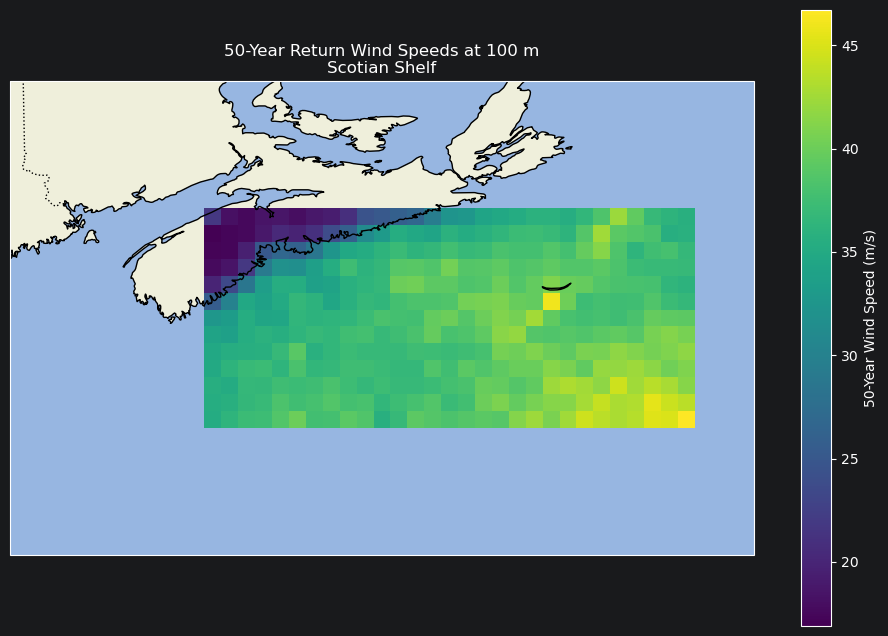

In [30]:
fig = plt.figure(figsize=(12,8))

ax = plt.axes(projection=ccrs.PlateCarree())

# Plot return levels
mesh = ax.pcolormesh(
    lon,
    lat,
    rl50,
    transform=ccrs.PlateCarree(),
    shading='auto'
)

# Add coastlines and map features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Focus on Nova Scotia / Scotian Shelf
ax.set_extent([-68, -57, 40, 47])

# Colorbar
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('50-Year Wind Speed (m/s)')

# Labels/title
plt.title('50-Year Return Wind Speeds at 100 m\nScotian Shelf')

plt.show()